In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
raw_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ams\hgm913.csv',sep=',',encoding='latin1') #Name the file as export
raw_datam=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ams\hgm913_columns.csv',sep=',',encoding='latin1') #Name the file as export_columns
raw_datam.rename(columns={'Unnamed: 1':'Message Type',
                                 'Unnamed: 2':'Protocole',
                                 'Unnamed: 3':'IMEI',
                                 'Unnamed: 4':'Serial',
                                 'Unnamed: 5':'Mileage',
                                 'Unnamed: 6':'Date',
                                 'Unnamed: 7':'Ignition',
                                 'Unnamed: 8':'Latitude',
                                 'Unnamed: 9':'Longitude',
                                 'Unnamed: 10':'Altitude',
                                 'Unnamed: 11':'External Power',
                                 'Unnamed: 12':'RPM',
                                 'Unnamed: 13':'Speed',
                                 'Unnamed: 14':'Satellite Number',
                                 'Unnamed: 15':'Azimuth',
                                 'Unnamed: 16':'Battery level',
                                 },inplace=True)
raw_datam.info()
raw_datam.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ams\export_nammed.csv')

<class 'pandas.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Message           830 non-null    str  
 1   Message Type      830 non-null    str  
 2   Protocole         830 non-null    str  
 3   IMEI              830 non-null    str  
 4   Serial            830 non-null    str  
 5   Mileage           830 non-null    str  
 6   Date              830 non-null    str  
 7   Ignition          830 non-null    str  
 8   Latitude          830 non-null    str  
 9   Longitude         830 non-null    str  
 10  Altitude          830 non-null    str  
 11  External Power    830 non-null    str  
 12  RPM               830 non-null    str  
 13  Speed             830 non-null    str  
 14  Satellite Number  830 non-null    str  
 15  Azimuth           830 non-null    str  
 16  Battery level     830 non-null    str  
 17  Unnamed: 17       830 non-null    str  
 18  U

In [28]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ams\export_nammed.csv',sep=',')
unit['Odometer in meters']=0.0
unit.info()
#unit_mileage=unit[unit['Date'].str.contains('2026-04-16T15')]
#unit_mileage[['Mileage','Date','IMEI']]

<class 'pandas.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          830 non-null    int64  
 1   Message             830 non-null    str    
 2   Message Type        830 non-null    str    
 3   Protocole           830 non-null    str    
 4   IMEI                830 non-null    str    
 5   Serial              830 non-null    str    
 6   Mileage             830 non-null    str    
 7   Date                830 non-null    str    
 8   Ignition            830 non-null    str    
 9   Latitude            830 non-null    str    
 10  Longitude           830 non-null    str    
 11  Altitude            830 non-null    str    
 12  External Power      830 non-null    str    
 13  RPM                 830 non-null    str    
 14  Speed               830 non-null    str    
 15  Satellite Number    830 non-null    str    
 16  Azimuth            

In [29]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ams\export_nammed.csv',sep=',')
unit_mileage=unit[unit['Date'].str.contains('2026')]
unit_mileage[['Mileage','Date','IMEI']]

,Mileage,Date,IMEI
0,Mileage:11713811,"Date:""2026-06-01T00:34:18Z""","Imei:""869487061675145"""
1,Mileage:11713811,"Date:""2026-06-01T01:34:18Z""","Imei:""869487061675145"""
2,Mileage:11713811,"Date:""2026-06-01T02:34:17Z""","Imei:""869487061675145"""
3,Mileage:11713811,"Date:""2026-06-01T03:34:18Z""","Imei:""869487061675145"""
4,Mileage:11713811,"Date:""2026-06-01T04:34:18Z""","Imei:""869487061675145"""
...,...,...,...
825,Mileage:11892580,"Date:""2026-06-05T15:36:12Z""","Imei:""869487061675145"""
826,Mileage:11892610,"Date:""2026-06-05T15:36:21Z""","Imei:""869487061675145"""
827,Mileage:11893162,"Date:""2026-06-05T15:38:02Z""","Imei:""869487061675145"""
828,Mileage:11893398,"Date:""2026-06-05T15:38:46Z""","Imei:""869487061675145"""


In [30]:
unit_odometer=unit[~unit['Protocole'].str.contains(':0')]
unit_odometer['Protocole'].value_counts()
#print("Unit odometer rows: ",unit_odometer.shape[0])

Protocole
ProtocolHeadType:19    778
ProtocolHeadType:20     52
Name: count, dtype: int64

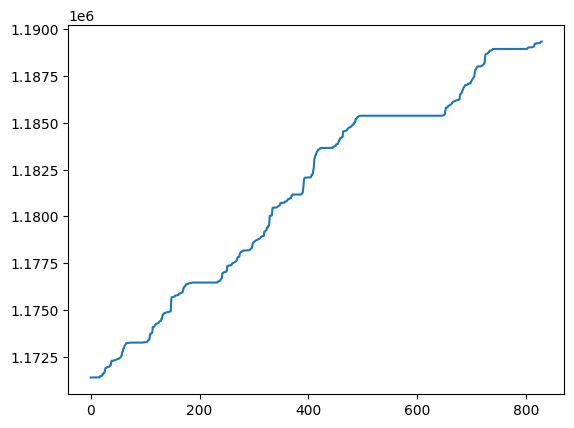

In [31]:
y_axis=[]
x_axis=[]
date=[]

for i in range(0,unit_odometer.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit_odometer.iloc[i,6][8:15]))
    x_axis.append(i)
    date.append(unit_odometer.iloc[i,7])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

#for i in range(0,unit_odometer.shape[0]):
#    print(date[i],' -> ',x_axis[i],y_axis[i])

plt.plot(x_axis,y_axis)

In [32]:
print(y_axis[len(y_axis)-1]-y_axis[0])

17967.0


In [33]:
hl=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ams\historicallocations.xlsx')
hl.info()

<class 'pandas.DataFrame'>
RangeIndex: 819 entries, 0 to 818
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Secuencia       819 non-null    int64  
 1   Unidad          819 non-null    str    
 2   Eventos         819 non-null    str    
 3   Fecha           819 non-null    str    
 4   Pt. Referencia  0 non-null      float64
 5   Dirección       819 non-null    str    
 6   Velocidad       819 non-null    int64  
 7   Temperatura     0 non-null      float64
 8   Conductor       0 non-null      float64
 9   Latitud         819 non-null    float64
 10  Longitud        819 non-null    float64
dtypes: float64(5), int64(2), str(4)
memory usage: 70.5 KB


In [34]:
hl['Eventos'].value_counts()

Eventos
Desplazándose - Ign. apagada    369
Idle - Stop                     230
Estacionado                     155
Ignición Apagada                 26
Ignición Encendida               26
Conduciendo                      13
Name: count, dtype: int64

In [35]:
hl_conduciendo=hl[hl['Eventos'].str.contains('Conduciendo')]
hl_conduciendo

,Secuencia,Unidad,Eventos,Fecha,Pt. Referencia,Dirección,Velocidad,Temperatura,Conductor,Latitud,Longitud
10,809,HGM913,Conduciendo,Jun 05 2026 09:48 AM,NaN,"Kr66 46-60, Santa Marta, Magdalena",17,NaN,NaN,11.214961,-74.163124
11,808,HGM913,Conduciendo,Jun 05 2026 09:47 AM,NaN,"Kr66 46-66, Santa Marta, Magdalena, Colombia",6,NaN,NaN,11.214688,-74.162666
12,807,HGM913,Conduciendo,Jun 05 2026 09:46 AM,NaN,"South America, Santa Marta, Magdalena",6,NaN,NaN,11.215302,-74.161827
18,801,HGM913,Conduciendo,Jun 05 2026 09:21 AM,NaN,"Kr66 46-49, Santa Marta, Magdalena, Colombia",6,NaN,NaN,11.215099,-74.161331
19,800,HGM913,Conduciendo,Jun 05 2026 09:21 AM,NaN,"Kr66 46-38, Santa Marta, Magdalena",6,NaN,NaN,11.214936,-74.160889
20,799,HGM913,Conduciendo,Jun 05 2026 09:20 AM,NaN,"Kr66a 47-39, Santa Marta, Magdalena",25,NaN,NaN,11.213546,-74.161713
22,797,HGM913,Conduciendo,Jun 05 2026 09:18 AM,NaN,"Cl52 66b-94, Santa Marta, Magdalena",14,NaN,NaN,11.208275,-74.162895
23,796,HGM913,Conduciendo,Jun 05 2026 09:17 AM,NaN,"Cra. 66 #50-314 a 50-436, Santa Marta, Magdale...",9,NaN,NaN,11.208176,-74.163094
435,384,HGM913,Conduciendo,Jun 03 2026 05:06 PM,NaN,"Via Principal-50, Santa Marta, Magdalena",56,NaN,NaN,11.217921,-74.190430
436,383,HGM913,Conduciendo,Jun 03 2026 05:05 PM,NaN,"Cl30-44, Santa Marta, Magdalena",61,NaN,NaN,11.219868,-74.184387
